In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Binarize the target labels for multiclass ROC-AUC calculation
binarizer = LabelBinarizer()
y_bin_train = binarizer.fit_transform(y_train)
y_bin_test = binarizer.transform(y_test)

# Store unique classes and number of classes
classes = binarizer.classes_
n_classes = len(classes)

print("Iris dataset loaded, split, scaled, and binarized successfully.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_bin_train shape: {y_bin_train.shape}")
print(f"y_bin_test shape: {y_bin_test.shape}")
print(f"Classes: {classes}")
print(f"Number of classes: {n_classes}")

Iris dataset loaded, split, scaled, and binarized successfully.
X_train_scaled shape: (105, 4)
X_test_scaled shape: (45, 4)
y_bin_train shape: (105, 3)
y_bin_test shape: (45, 3)
Classes: [0 1 2]
Number of classes: 3


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
import numpy as np
import pandas as pd

# Initialize classifiers
models = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Logistic Regression': OneVsRestClassifier(LogisticRegression(random_state=42)), # Wrap LogisticRegression with OneVsRestClassifier
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

results = {}
roc_data = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Calculate standard classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    # For multiclass, precision, recall, f1_score need 'macro' average
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    }

    # Predict probabilities for ROC curve
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_scaled)
        # For SVM, decision_function output is not normalized probabilities
        # For multiclass with 'ovr', need to handle it. For plotting, predict_proba is preferred.
        # If predict_proba is not available, we might need a workaround or skip ROC for that model.
        # Given SVC(probability=True) is used, predict_proba should be available.
    else:
        y_score = None

    if y_score is not None:
        # Compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_bin_test[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Compute macro-average ROC curve and ROC area
        # Aggregate all false positive rates
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

        # Interpolate all ROC curves at these points
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

        # Average it and compute AUC
        mean_tpr /= n_classes

        fpr["macro"] = all_fpr
        tpr["macro"] = mean_tpr
        roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

        roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc["macro"]}
    else:
        print(f"Warning: {name} does not support probability prediction for ROC curve.")

# Convert results to DataFrame
df_results = pd.DataFrame(results).T
df_results = df_results.round(4)

print("\nClassification Results\n")
print(df_results)

Training KNN...
Training Decision Tree...
Training Logistic Regression...
Training SVM...
Training Naive Bayes...

Classification Results

                     Accuracy  Precision  Recall      F1
KNN                    1.0000     1.0000  1.0000  1.0000
Decision Tree          1.0000     1.0000  1.0000  1.0000
Logistic Regression    0.9111     0.9216  0.8974  0.8949
SVM                    1.0000     1.0000  1.0000  1.0000
Naive Bayes            0.9778     0.9762  0.9744  0.9743


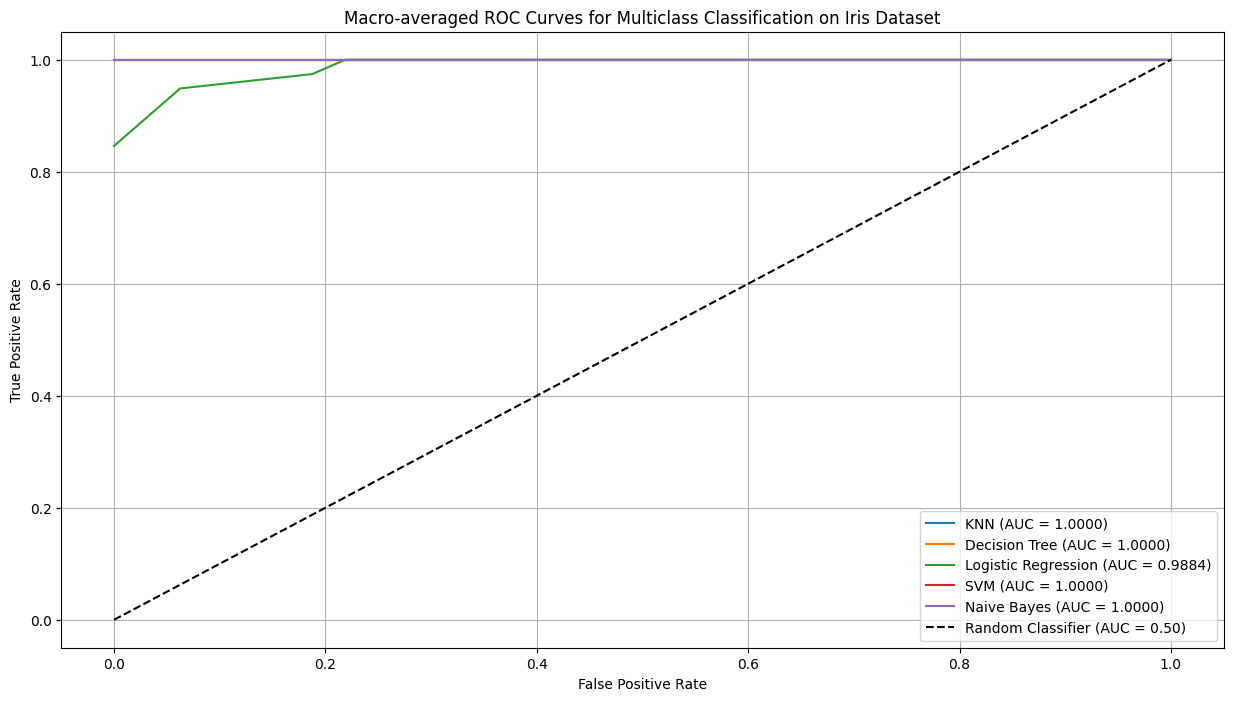

ROC curves plotted successfully.


In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

# Plot ROC curves for each classifier
for name, data in roc_data.items():
    plt.plot(data['fpr']['macro'], data['tpr']['macro'],
             label=f'{name} (AUC = {data["auc"]:.4f})')

# Plot the diagonal random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-averaged ROC Curves for Multiclass Classification on Iris Dataset')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("ROC curves plotted successfully.")